In [ ]:
from typing import TypedDict
class PortFolioState(TypedDict):
    amount_usd : float
    total_usd : float
    total_inr : float

In [3]:
def calc_total(state : PortFolioState)->PortFolioState:
    state['total_usd'] = state['amount_usd']* 1.08
    
    return state
    

In [ ]:
def convert_to_inr(state: PortFolioState)->PortFolioState:
    state['total_inr'] = state['total_usd'] * 97.03
    return state

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortFolioState)

builder.add_node("calc_total_node",calc_total)
builder.add_node("cvrt_to_inr_node",convert_to_inr)

builder.add_edge(START, "calc_total_node")
builder.add_edge("calc_total_node", "cvrt_to_inr_node")
builder.add_edge("cvrt_to_inr_node", END)

graph = builder.compile()

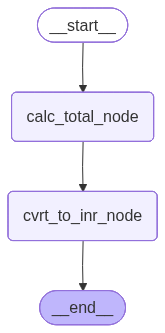

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"amount_usd" : 1000})

{'amount_usd': 1000, 'total_usd': 1080.0, 'total_inr': 104792.4}